In [1]:
import pandas as pd
import numpy as np


raw_data = pd.read_csv("../raw_data/nfl_odds_2007-2022.csv", parse_dates=["date"])
raw_data.head()

,date,away_team,home_team,away_score,home_score,away_ml,home_ml,away_spread,home_spread,close_total,season,home_win
0,2007-09-06,NewOrleans,Indianapolis,10,41,200,-240,0.0,5.5,52.5,2007-08,1.0
1,2007-09-09,KansasCity,HoustonTexans,3,20,170,-200,0.0,3.0,37.5,2007-08,1.0
2,2007-09-09,Denver,Buffalo,15,14,-170,150,3.0,0.0,38.5,2007-08,0.0
3,2007-09-09,Pittsburgh,Cleveland,34,7,-235,195,5.0,0.0,36.0,2007-08,0.0
4,2007-09-09,Tennessee,Jacksonville,13,10,290,-350,0.0,7.5,39.5,2007-08,0.0


### No-vig (Vig removal)
Every line (moneyline, closed spread, closed total) all have some "juice" in it which is a percentage that the house makes. Removing the vig is needed to convert the odds to implied probabilities. Not removing vig would lead to probabilities >100% due to the built in edge. 

In [2]:
def ml_implied_prob(ml):
    """Raw (vig-included) implied win probability for one moneyline.

    Negative odds (favorite) and positive odds (underdog) use different
    formulas. this picks the right one based on the ML's own sign,
    since either the home or away team can be the favorite.

    return : PD series of implied probs
    """
    return pd.Series(np.where(ml < 0, -ml / (-ml + 100), 100 / (ml + 100)), index=ml.index)


def ml_vig_prob():
    """Removes the vig from moneyline.

    return : Implied probability for the game (home and away)
    """

    #The individual probabilities for home and away to win the game
    home_ml_prob = ml_implied_prob(raw_data['home_ml'])
    away_ml_prob = ml_implied_prob(raw_data['away_ml'])

    total_prob = home_ml_prob + away_ml_prob
    raw_data['vig_prob'] = round(total_prob - 1, 2)

    #Removing the Vig (normalized prob)
    raw_data["home_ml_prob"] = round(home_ml_prob / total_prob , 2)
    raw_data["away_ml_prob"] = round(away_ml_prob / total_prob, 2) 

    #Probabilities in dictionary will not add up to 1 because the home and away
    #probaility are already normalized and the vig was from before they were normalized

ml_vig_prob()
raw_data.head()

,date,away_team,home_team,away_score,home_score,away_ml,home_ml,away_spread,home_spread,close_total,season,home_win,vig_prob,home_ml_prob,away_ml_prob
0,2007-09-06,NewOrleans,Indianapolis,10,41,200,-240,0.0,5.5,52.5,2007-08,1.0,0.04,0.68,0.32
1,2007-09-09,KansasCity,HoustonTexans,3,20,170,-200,0.0,3.0,37.5,2007-08,1.0,0.04,0.64,0.36
2,2007-09-09,Denver,Buffalo,15,14,-170,150,3.0,0.0,38.5,2007-08,0.0,0.03,0.39,0.61
3,2007-09-09,Pittsburgh,Cleveland,34,7,-235,195,5.0,0.0,36.0,2007-08,0.0,0.04,0.33,0.67
4,2007-09-09,Tennessee,Jacksonville,13,10,290,-350,0.0,7.5,39.5,2007-08,0.0,0.03,0.75,0.25


In [3]:
import statsmodels.api as sm
def spread_prob():
    """
    Determines probability of home/away team win based on closed spread
    using logistic regression.

    Uses both away_spread and home_spread as predictors. Only one of the
    two is ever nonzero for a given game (whichever team is favored), so
    together they tell the model both the size of the spread and which
    team it favors, a single unsigned spread column can't do that.

    return : Adds two columns: home_spread_prob (home team win probability) and
    away_spread_prob (away team win probability, i.e. 1 - home_spread_prob).
    """
    #fitting the data
    X = sm.add_constant(raw_data[["away_spread", "home_spread"]])
    model = sm.Logit(raw_data["home_win"], X).fit()

    home_win_prob = model.predict(X)
    raw_data["home_spread_prob"] = round(home_win_prob, 2)
    raw_data["away_spread_prob"] = round(1 - home_win_prob, 2)

    
spread_prob()
raw_data.head(10)

Optimization terminated successfully.
         Current function value: 0.608198
         Iterations 5


,date,away_team,home_team,away_score,home_score,away_ml,home_ml,away_spread,home_spread,close_total,season,home_win,vig_prob,home_ml_prob,away_ml_prob,home_spread_prob,away_spread_prob
0,2007-09-06,NewOrleans,Indianapolis,10,41,200,-240,0.0,5.5,52.5,2007-08,1.0,0.04,0.68,0.32,0.68,0.32
1,2007-09-09,KansasCity,HoustonTexans,3,20,170,-200,0.0,3.0,37.5,2007-08,1.0,0.04,0.64,0.36,0.58,0.42
2,2007-09-09,Denver,Buffalo,15,14,-170,150,3.0,0.0,38.5,2007-08,0.0,0.03,0.39,0.61,0.38,0.62
3,2007-09-09,Pittsburgh,Cleveland,34,7,-235,195,5.0,0.0,36.0,2007-08,0.0,0.04,0.33,0.67,0.33,0.67
4,2007-09-09,Tennessee,Jacksonville,13,10,290,-350,0.0,7.5,39.5,2007-08,0.0,0.03,0.75,0.25,0.74,0.26
5,2007-09-09,Carolina,St.Louis,27,13,105,-125,0.0,2.5,43.0,2007-08,0.0,0.04,0.53,0.47,0.57,0.43
6,2007-09-09,Philadelphia,GreenBay,13,16,-190,160,3.0,0.0,41.5,2007-08,1.0,0.04,0.37,0.63,0.38,0.62
7,2007-09-09,Atlanta,Minnesota,3,24,150,-170,0.0,3.0,34.0,2007-08,1.0,0.03,0.61,0.39,0.58,0.42
8,2007-09-09,Miami,Washington,13,16,155,-175,0.0,3.0,34.0,2007-08,1.0,0.03,0.62,0.38,0.58,0.42
9,2007-09-09,NewEngland,NYJets,38,14,-260,220,6.0,0.0,41.5,2007-08,0.0,0.03,0.30,0.70,0.30,0.70


In [4]:
def implied_score():
    """
    Determines what the implied score is using the closed total and spread for home
    and away teams. 

    Does not return any probabilities based on total but rather
    what each team is implied to score.

    return : Adds two columns for implied score for home and away teams
    """

    raw_data["h_impScore"] = (raw_data["close_total"] + raw_data["home_spread"] - raw_data["away_spread"]) / 2
    raw_data["a_impScore"] = (raw_data["close_total"] + raw_data["away_spread"] - raw_data["home_spread"]) / 2

implied_score()
raw_data.head()

,date,away_team,home_team,away_score,home_score,away_ml,home_ml,away_spread,home_spread,close_total,season,home_win,vig_prob,home_ml_prob,away_ml_prob,home_spread_prob,away_spread_prob,h_impScore,a_impScore
0,2007-09-06,NewOrleans,Indianapolis,10,41,200,-240,0.0,5.5,52.5,2007-08,1.0,0.04,0.68,0.32,0.68,0.32,29.00,23.50
1,2007-09-09,KansasCity,HoustonTexans,3,20,170,-200,0.0,3.0,37.5,2007-08,1.0,0.04,0.64,0.36,0.58,0.42,20.25,17.25
2,2007-09-09,Denver,Buffalo,15,14,-170,150,3.0,0.0,38.5,2007-08,0.0,0.03,0.39,0.61,0.38,0.62,17.75,20.75
3,2007-09-09,Pittsburgh,Cleveland,34,7,-235,195,5.0,0.0,36.0,2007-08,0.0,0.04,0.33,0.67,0.33,0.67,15.50,20.50
4,2007-09-09,Tennessee,Jacksonville,13,10,290,-350,0.0,7.5,39.5,2007-08,0.0,0.03,0.75,0.25,0.74,0.26,23.50,16.00


### Analyzing the new probabilities

After converting the moneyline odds and the spread, now we have to compare both to determine if they disagree. In addition, determine whether the disagreements predict outcomes

**H0**: A difference in win probability (implied) between moneyline and spread has no relationship with actual game outcomes

**HA:** A difference in win probability (implied) does have an association with the actual probability of a home win

If the market is fully efficient, `home_prob_diff` should have no relationship to outcomes but a significant non-zero coefficient would suggest the markets are not perfectly reconciled.

**Sig level = .05**

In [5]:
import statsmodels.api as sm

#comparing difference between moneyline prob and spread prob
home_prob_diff = pd.Series(raw_data['home_ml_prob'] - raw_data['home_spread_prob'])

disagreement = sm.add_constant(home_prob_diff)
dis_model = sm.Logit(raw_data["home_win"], disagreement).fit()
print(dis_model.summary())

Optimization terminated successfully.
         Current function value: 0.684910
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:               home_win   No. Observations:                 4025
Model:                          Logit   Df Residuals:                     4023
Method:                           MLE   Df Model:                            1
Date:                Wed, 16 Sep 2026   Pseudo R-squ.:                0.001747
Time:                        16:15:32   Log-Likelihood:                -2756.8
converged:                       True   LL-Null:                       -2761.6
Covariance Type:            nonrobust   LLR p-value:                  0.001895
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2738      0.034      8.083      0.000       0.207       0.340
0             -3.9517      1.

The p-value for the coefficient of `home_prob_diff` is less than .05; therefore, I reject the null hypothesis. There is a statistically significant association between the difference in the home teams moneyline and spread implied win probability and the game outcome.

**However** , the effect size is modest at best since the Pseudo R-squ is .0017 meaning `home_prob_diff` explains a very small share of the variance in game outcome. The relationship is real but small.

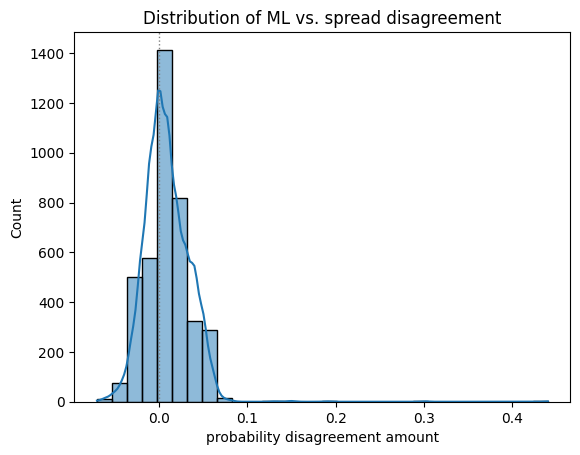

count    4025.000000
mean        0.008924
std         0.025178
min        -0.070000
25%        -0.010000
50%         0.010000
75%         0.020000
max         0.440000
dtype: float64

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(home_prob_diff, bins=30, kde=True)
plt.axvline(0, color="gray", linestyle=":", linewidth=1)
plt.xlabel("probability disagreement amount")
plt.title("Distribution of ML vs. spread disagreement")
plt.savefig("home_prob_diff_hist.png", dpi=150)
plt.show()

home_prob_diff.describe()